In [3]:
!pip install ultralytics -q
!pip install roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 82.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 36.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
from ultralytics import YOLO
import ultralytics

import roboflow

import glob

import cv2
import numpy as np
import os

from matplotlib import pyplot as plt

import pandas as pd

from IPython import display
display.clear_output()

from IPython.display import display, Image

HOME = os.getcwd()
print(HOME)

RANDOM_STATE = 280625

ModuleNotFoundError: No module named 'ultralytics'

In [2]:
ultralytics.checks()

NameError: name 'ultralytics' is not defined

In [4]:
rf = roboflow.Roboflow(api_key='3sllSNniQTyalwdteomI')

In [5]:
project = rf.workspace("floorplans-gmxhd").project("auto_multi_annotations")

loading Roboflow workspace...
loading Roboflow project...


In [6]:
dataset = project.version(2).download("yolov11")


Extracting Dataset Version Zip to auto_multi_annotations-2 in yolov11:: 100%|██████████| 19410/19410 [00:02<00:00, 7584.17it/s] 


In [7]:
DS_LOC = dataset.location

In [8]:
model = YOLO(f'{HOME}/yolo11s.pt')

100%|██████████| 18.4M/18.4M [00:00<00:00, 161MB/s]


In [9]:
train_results = model.train(data=f"{DS_LOC}/data.yaml",
            epochs=100,
            batch=-1,
            device=-1,
            seed=RANDOM_STATE,
            fraction=0.5,
            plots=True,
            conf=0.3,
            patience=10,
            project="window_door_detect_project",
            name="window_door_detect_model"
            )

Searching for 1 idle GPUs with free memory >= 20.0% and free utilization >= 0.0%...
Selected idle CUDA devices [0]
Ultralytics 8.3.161 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=0.3, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/auto_multi_annotations-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.5, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=win

100%|██████████| 755k/755k [00:00<00:00, 17.0MB/s]


Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.block.C3k2            [256, 256, 1, True]           
  7                  -1  1   1180672  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 73.2MB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1303.3±446.1 MB/s, size: 61.1 KB)


...

train: Scanning /kaggle/working/auto_multi_annotations-2/train/labels.cache... 4296 images, 31 backgrounds, 0 corrupt: 100%|██████████| 4296/4296 [00:00<?, ?it/s]

train: /kaggle/working/auto_multi_annotations-2/train/images/1000_F1_scaled_png.rf.653e16f1af61a06076002192d293380c.jpg: 408 duplicate labels removed
train: /kaggle/working/auto_multi_annotations-2/train/images/1000_F1_scaled_png.rf.a8cb72aad2c368a23c29dc91ae6d9759.jpg: 408 duplicate labels removed
train: /kaggle/working/auto_multi_annotations-2/train/images/1000_F1_scaled_png.rf.d576b0879e7ffb01938019764e4944d9.jpg: 408 duplicate labels removed
train: /kaggle/working/auto_multi_annotations-2/train/images/1001_F1_scaled_png.rf.146c9fe3ff1d0fc969cb93e5854bc432.jpg: 32 duplicate labels removed
train: /kaggle/working/auto_multi_annotations-2/train/images/1001_F1_scaled_png.rf.e4dc4a944305ad2ca408a70b7b3f061f.jpg: 32 duplicate labels removed
train: /kaggle/working/auto_multi_annotations-2/train/images/1002_F1_scaled_png.rf.0d7e5d55bb1eb7138a67762968116efa.jpg: 81 duplicate labels removed
train: /kaggle/working/auto_multi_annotations-2/train/images/1002_F1_scaled_png.rf.6770165c0e39470e8e0a

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 612.9±192.2 MB/s, size: 47.0 KB)


val: Scanning /kaggle/working/auto_multi_annotations-2/valid/labels... 83 images, 0 backgrounds, 0 corrupt:   9%|▉         | 83/904 [00:00<00:01, 672.78it/s]


KeyboardInterrupt: 

In [11]:
metrics = model.val()

Ultralytics 8.3.161 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:1 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1119.6±273.0 MB/s, size: 32.2 KB)


val: Scanning /kaggle/working/auto_multi_annotations-2/valid/labels.cache... 904 images, 6 backgrounds, 0 corrupt: 100%|██████████| 904/904 [00:00<?, ?it/s]

val: /kaggle/working/auto_multi_annotations-2/valid/images/1010_F1_scaled_png.rf.23d53dc7783832c8cac57bfcdeb661df.jpg: 36 duplicate labels removed
val: /kaggle/working/auto_multi_annotations-2/valid/images/1011_F1_scaled_png.rf.8f5210479bc2848f5ca67b1299ce1a05.jpg: 24 duplicate labels removed
val: /kaggle/working/auto_multi_annotations-2/valid/images/1014_F1_scaled_png.rf.eded19dffcec683e17e018c752e84a1e.jpg: 108 duplicate labels removed
val: /kaggle/working/auto_multi_annotations-2/valid/images/1019_F1_scaled_png.rf.9a606a7b53c8ecc665c550cd255cbafc.jpg: 528 duplicate labels removed
val: /kaggle/working/auto_multi_annotations-2/valid/images/1020_F1_scaled_png.rf.17a08ac424fecff13556ae892552225c.jpg: 493 duplicate labels removed
val: /kaggle/working/auto_multi_annotations-2/valid/images/1022_F1_scaled_png.rf.8789fa6870375dc65ea317e92590a63f.jpg: 165 duplicate labels removed
val: /kaggle/working/auto_multi_annotations-2/valid/images/1023_F1_scaled_png.rf.86e3c6df313c8c7dde331e409bfd51a3.


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 57/57 [00:14<00:00,  4.01it/s]
invalid value encountered in less
invalid value encountered in less


                   all        904      15876      0.906      0.888      0.911      0.709
                  door        898       8616      0.948      0.959      0.962      0.824
                window        892       7260      0.863      0.817       0.86      0.595
Speed: 0.4ms preprocess, 10.2ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to runs/detect/train22


In [11]:
metrics_test = model.val(split='test')

Ultralytics 8.3.161 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:1 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 891.4±198.4 MB/s, size: 47.9 KB)


val: Scanning /kaggle/working/auto_multi_annotations-2/test/labels... 202 images, 0 backgrounds, 0 corrupt: 100%|██████████| 202/202 [00:00<00:00, 769.87it/s]

val: /kaggle/working/auto_multi_annotations-2/test/images/1018_F1_scaled_png.rf.500daa229485949de9eeb05855bde686.jpg: 18 duplicate labels removed
val: /kaggle/working/auto_multi_annotations-2/test/images/1029_F1_scaled_png.rf.e3b1c01f3a40edaf5fa74661bcb2d379.jpg: 616 duplicate labels removed
val: /kaggle/working/auto_multi_annotations-2/test/images/1044_F1_scaled_png.rf.2dc6eeace04796a41d99c8e43db83830.jpg: 25 duplicate labels removed
val: /kaggle/working/auto_multi_annotations-2/test/images/1050_F1_scaled_png.rf.19b525c311a622ae7c81960042c48143.jpg: 171 duplicate labels removed
val: /kaggle/working/auto_multi_annotations-2/test/images/1106_F1_scaled_png.rf.c8c269c7f07f290e6f94212562a58c2b.jpg: 228 duplicate labels removed
val: /kaggle/working/auto_multi_annotations-2/test/images/1109_F1_scaled_png.rf.cc9ddd52d09dc169cada76e7fb541a6b.jpg: 40 duplicate labels removed
val: /kaggle/working/auto_multi_annotations-2/test/images/1126_F1_scaled_png.rf.c0a882af4f5ff8f0dfa86bacb893199e.jpg: 18 


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 41/41 [00:04<00:00,  9.56it/s]
invalid value encountered in less
invalid value encountered in less


                   all        202       3872      0.896      0.842      0.894      0.707
                  door        202       2006      0.951      0.941      0.961      0.832
                window        201       1866      0.841      0.742      0.827      0.583
Speed: 1.0ms preprocess, 11.3ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to runs/detect/train22


In [12]:
metrics_test.to_df()

,Class,Images,Instances,Box-P,Box-R,Box-F1,mAP50,mAP50-95
0,door,202,2006,0.95066,0.94133,0.94597,0.96131,0.83229
1,window,201,1866,0.84120,0.74223,0.78862,0.82677,0.58263


In [33]:
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        if (filename.endswith(".png")):
            img = cv2.imread(os.path.join(folder,filename))
            if img is not None:
                images.append(img)
    return images

def show_images_cv2(images):
    for i, img in enumerate(images):
        plt.figure(figsize=(10, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.show()

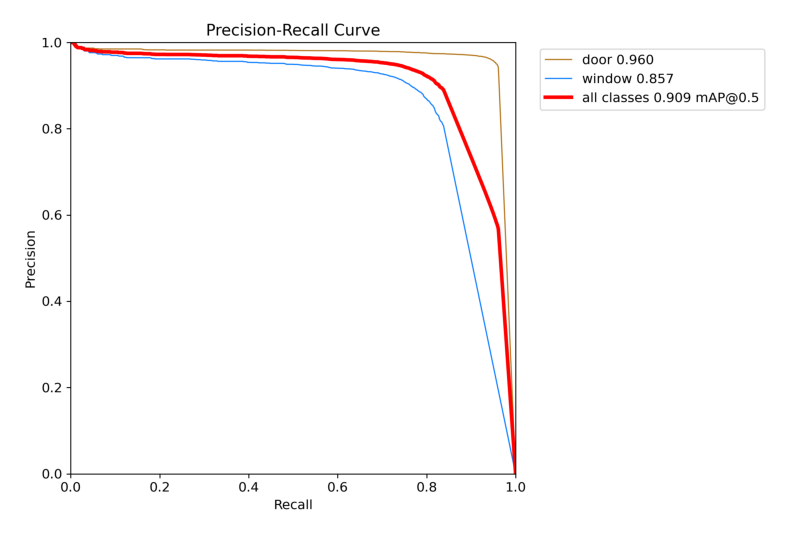

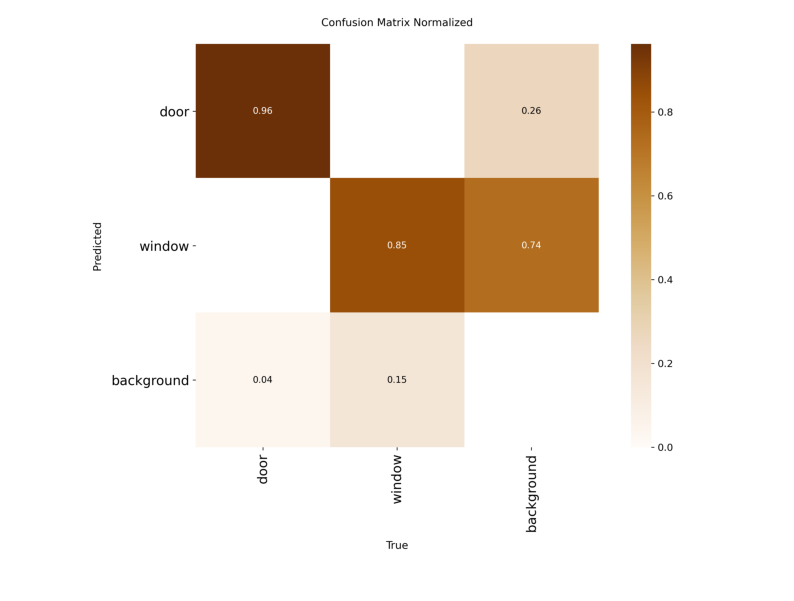

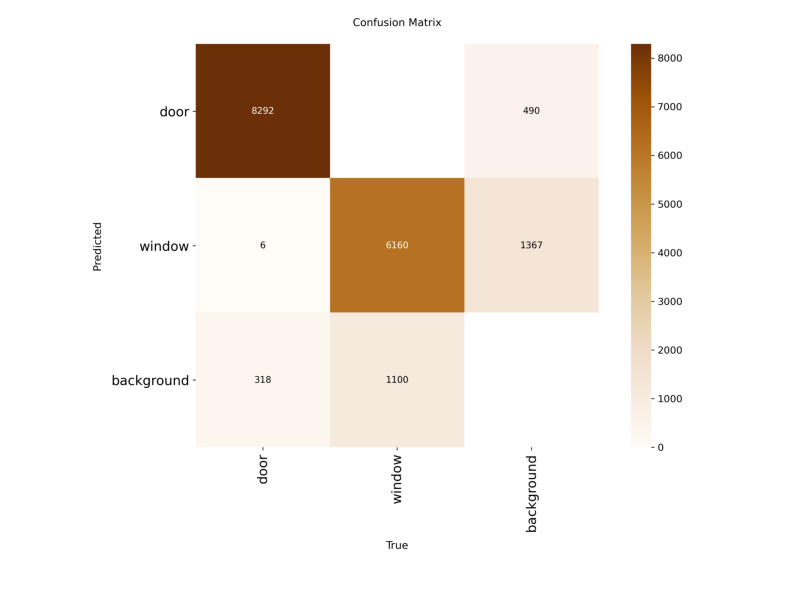

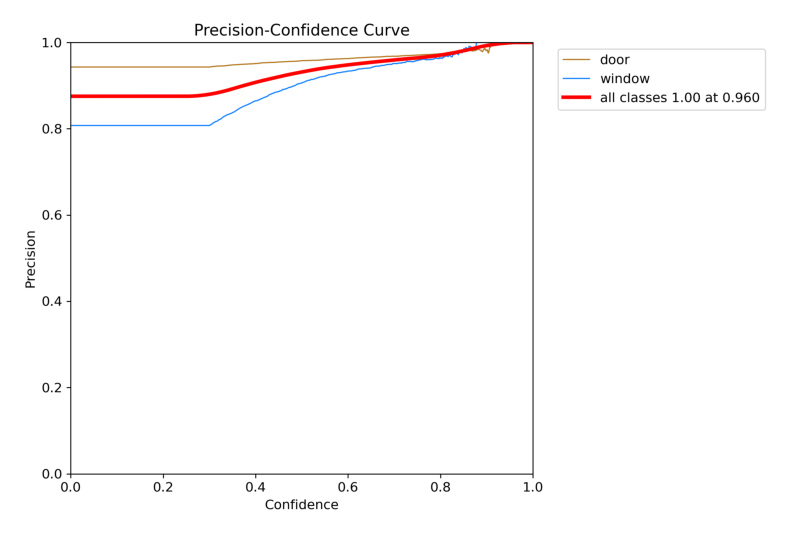

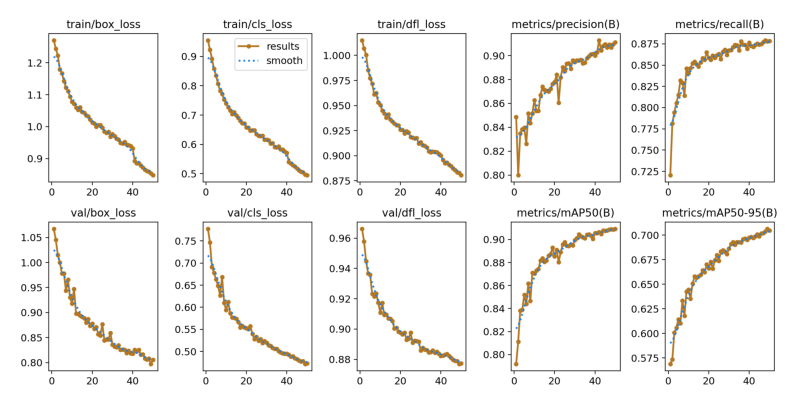

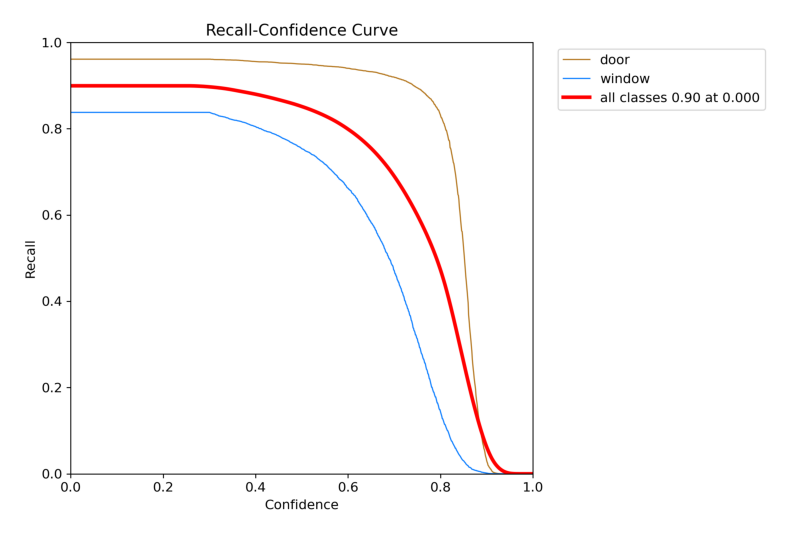

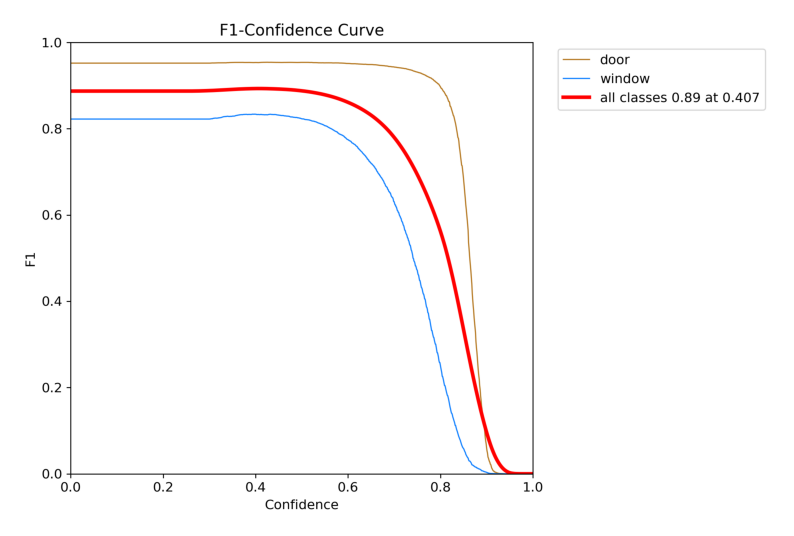

In [34]:
metric_img = load_images_from_folder('/kaggle/working/runs/detect/train2')
show_images_cv2(metric_img)

In [36]:
train_results = pd.read_csv(os.path.join('/kaggle/working/runs/detect/train2', 'results.csv'))

In [38]:
trained_model = YOLO(f'{HOME}/runs/detect/train2/weights/best.pt')

In [39]:
test_results = trained_model.predict(f'{HOME}/auto_multi_annotations-2/test/images', save=True, verbose=False, conf=0.6)

Results saved to runs/detect/predict2


In [51]:
pd.DataFrame(test_results).head()

,0
0,(((ultralytics.engine.results.Results object w...
1,(((ultralytics.engine.results.Results object w...
2,(((ultralytics.engine.results.Results object w...
3,(((ultralytics.engine.results.Results object w...
4,(((ultralytics.engine.results.Results object w...


In [46]:
base_path = f'{HOME}/auto_multi_annotations-2/runs/detect/predict2'

In [50]:
test_output = {} 

for result in test_results:
    for box in result.boxes:
        test_output.append({
            'file_name'
            "class": model.names[int(box.cls)],
            "confidence": float(box.conf),
            "coordinates": box.xyxy[0].tolist()
        })

test_output_df = pd.DataFrame(test_output)

AttributeError: 'dict' object has no attribute 'append'

In [47]:
first_image_path = test_results[1].save_dir

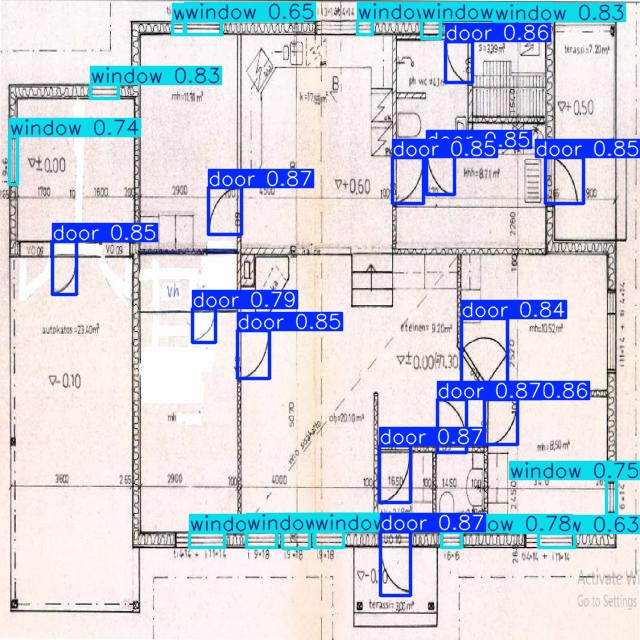

In [43]:
display(Image(filename=f'{first_image_path}/1106_F1_scaled_png.rf.c8c269c7f07f290e6f94212562a58c2b.jpg', width=600))

In [44]:
trained_model.predict('/kaggle/input/test-image/2025-06-24_16-55-44.png', save=True, verbose=False)

Results saved to runs/detect/predict2


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'door', 1: 'window'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
       

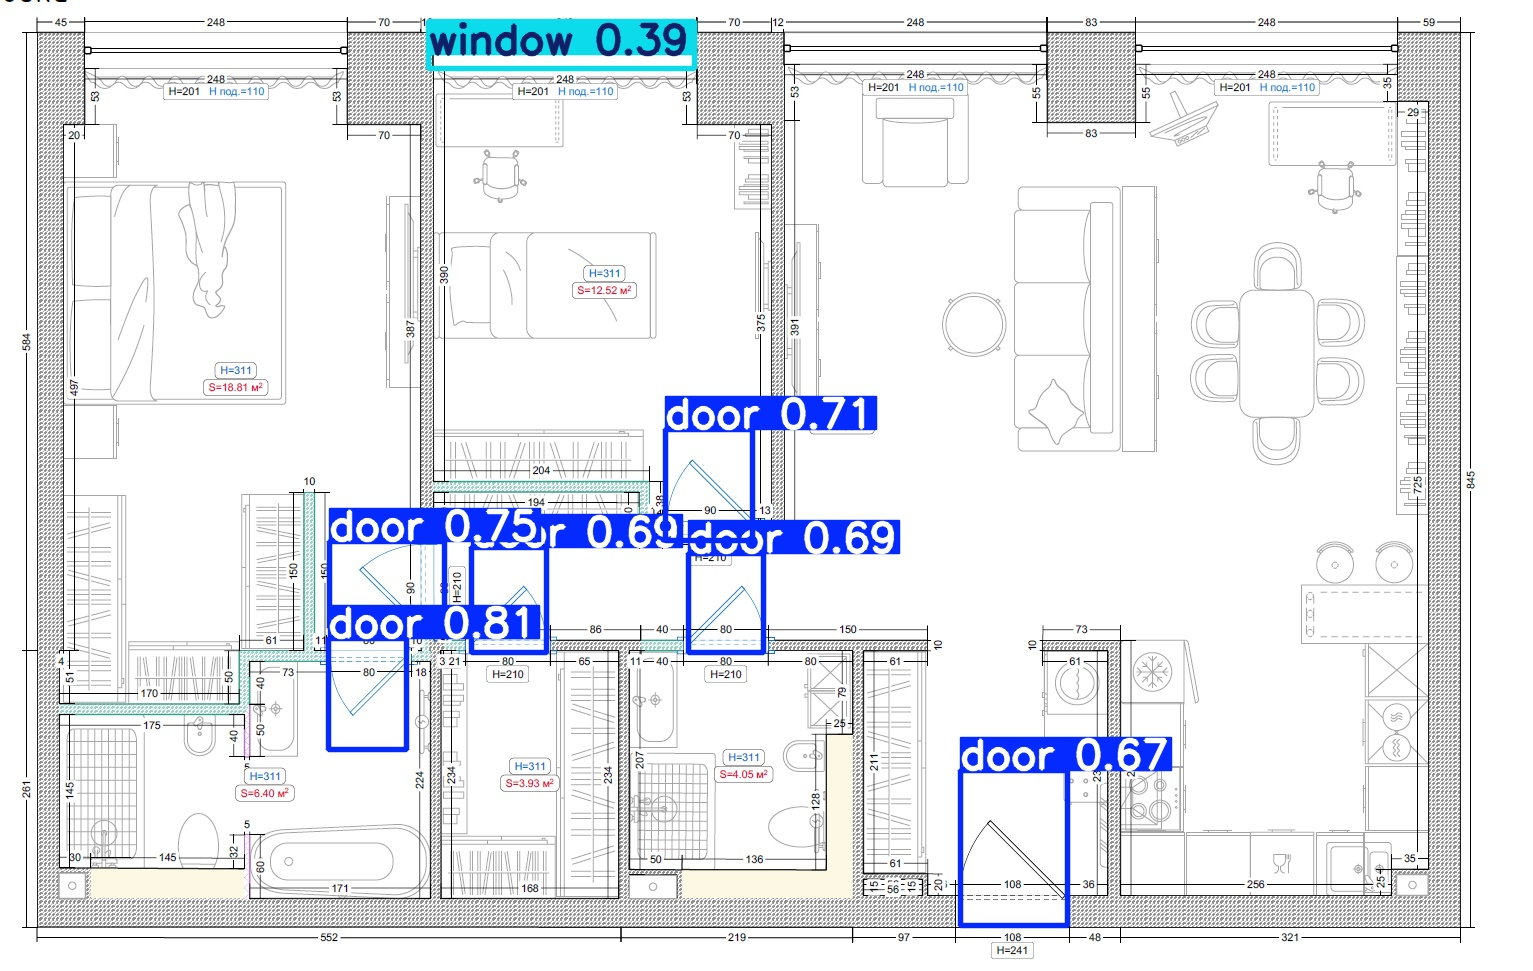

In [45]:
display(Image(filename=f'{first_image_path}/2025-06-24_16-55-44.jpg', width=600))